<a href="https://colab.research.google.com/github/KaustubhKoshti/Rapido-Data-Analytics-End-to-End-Project/blob/main/Model%20training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from os import initgroups
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
bookings = pd.read_csv('/content/sample_data/Booking.csv')
bookings.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for Cancelling by Customer,Cancelled Rides by Driver,Reason for Cancelling by Driver,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating
0,2025-01-21,14:55,CNR2373430247,Success,CUST907817,eBike,Area 3,Area 26,12.76,17.36,False,NaN,False,NaN,False,NaN,334.0,35.68,1.8,1.4
1,2025-01-13,14:46,CNR8825424090,Success,CUST359317,Bike,Area 3,Area 35,4.95,8.60,False,NaN,False,NaN,False,NaN,452.0,46.90,2.2,3.5
2,2025-01-20,02:54,CNR7869379373,Cancelled by Driver,CUST221126,Bike,Area 35,Area 48,NaN,NaN,False,NaN,True,Personal & Car related issues,False,NaN,NaN,NaN,NaN,NaN
3,2025-01-17,12:50,CNR2899177378,Success,CUST338656,Prime Sedan,Area 21,Area 5,12.24,12.38,False,NaN,False,NaN,False,NaN,420.0,42.66,4.5,1.9
4,2025-01-08,02:13,CNR4467207253,Success,CUST495153,eBike,Area 21,Area 18,9.69,6.06,False,NaN,False,NaN,False,NaN,370.0,41.75,1.5,4.1


In [24]:
bookings.shape


(100000, 20)

In [25]:
bookings.describe()


,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,66833.000000,66833.000000,66833.000000,66833.000000,66833.000000,66833.000000
mean,8.010105,15.496752,431.944354,45.702126,3.002939,2.996985
std,4.035576,8.389567,296.688043,29.711784,1.151638,1.154560
min,1.000000,1.000000,50.000000,5.000000,1.000000,1.000000
25%,4.500000,8.210000,210.000000,23.520000,2.000000,2.000000
50%,8.030000,15.480000,371.000000,39.550000,3.000000,3.000000
75%,11.500000,22.760000,587.000000,61.280000,4.000000,4.000000
max,15.000000,30.000000,2000.000000,203.940000,5.000000,5.000000


In [26]:
bookings.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,33167
Avg CTAT,33167


In [27]:
# Strategy 1: Fill numerical columns with median
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
bookings[num_cols] = bookings[num_cols].fillna(bookings[num_cols].median())

# Strategy 2: Fill categorical columns with a placeholder
cat_cols = ['Reason for Cancelling by Customer', 'Reason for Cancelling by Driver', 'Incomplete Rides Reason']
bookings[cat_cols] = bookings[cat_cols].fillna('Not Provided')

# Check if all missing values are handled
print(bookings.isnull().sum())


Date                                 0
Time                                 0
Booking ID                           0
Booking Status                       0
Customer ID                          0
Vehicle Type                         0
Pickup Location                      0
Drop Location                        0
Avg VTAT                             0
Avg CTAT                             0
Cancelled Rides by Customer          0
Reason for Cancelling by Customer    0
Cancelled Rides by Driver            0
Reason for Cancelling by Driver      0
Incomplete Rides                     0
Incomplete Rides Reason              0
Booking Value                        0
Ride Distance                        0
Driver Ratings                       0
Customer Rating                      0
dtype: int64


In [28]:
label_encoders = {}
for col in bookings.select_dtypes(include='object').columns:
    le = LabelEncoder()
    bookings[col] = le.fit_transform(bookings[col])
    label_encoders[col] = le

# Define features and target
X = bookings.drop('Booking Status', axis=1)
y = bookings['Booking Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test_scaled)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 1.0

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1500
           1       1.00      1.00      1.00      3850
           2       1.00      1.00      1.00      1331
           3       1.00      1.00      1.00     13319

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



✅ Accuracy: 100.00%


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


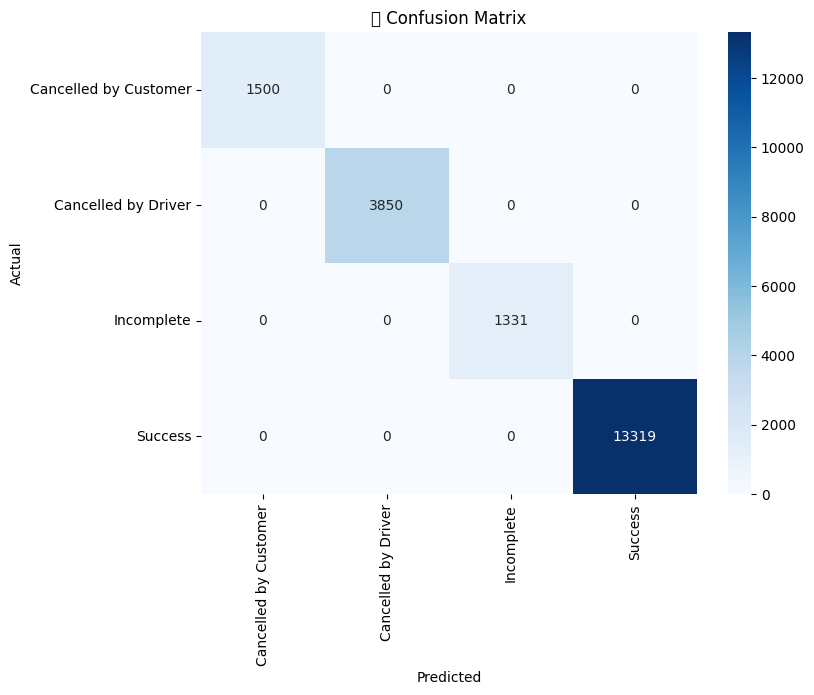

In [29]:
# Accuracy percentage
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"✅ Accuracy: {accuracy:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoders['Booking Status'].classes_, yticklabels=label_encoders['Booking Status'].classes_)
plt.title("🔍 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()